In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

normalized_data = pd.read_csv('/content/drive/MyDrive/HALE-Data/normalized.csv')


Mounted at /content/drive


In [ ]:
X = normalized_data.drop(columns=['HALE_60'])
y = normalized_data['HALE_60']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(X_test)

      Period  HALE_Birth  \
2483    2007    0.782392   
1498    2019    0.861715   
5438    2012   -0.804059   
7317    2019    1.694602   
6380    2006    0.504763   
...      ...         ...   
227     2015   -1.240333   
7585    2008    1.179005   
8224    2001   -1.478301   
8543    2007   -0.367785   
1508    2002   -1.359317   

      infant mortality rate (between birth and 11 months per 1000 live births)  \
2483                                          -0.868256                          
1498                                          -0.897836                          
5438                                           0.901603                          
7317                                          -1.015776                          
6380                                          -0.306998                          
...                                                 ...                          
227                                            1.322926                          
7585   

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    min_samples_split=10,
    oob_score=True,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("=" * 55)
print("  Best Model:  Random Forest")
print("=" * 55)
print(f"  Test R²  : {r2_score(y_test, y_pred):.4f}")
print(f"  Test MSE : {mean_squared_error(y_test, y_pred):.4f}")
print(f"  OOB Score: {rf_model.oob_score_:.4f}")
print("=" * 55)

  Best Model:  Random Forest
  Test R²  : 0.9905
  Test MSE : 0.0094
  OOB Score: 0.9902


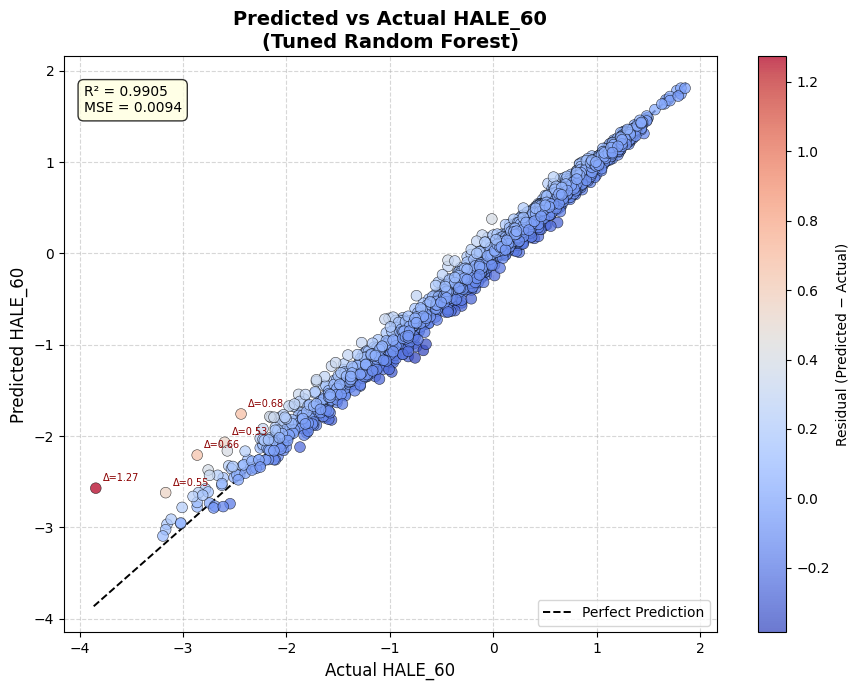

Plot saved: predicted_vs_actual_hale60.png


In [ ]:
# ── 2. Predicted vs Actual HALE_60 Values ───────────────────
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    y_test, y_pred,
    c=(y_pred - y_test),          # colour = residual
    cmap='coolwarm', alpha=0.75,
    edgecolors='k', linewidths=0.4, s=60, zorder=3
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Residual (Predicted − Actual)', fontsize=10)
# Perfect-prediction line
lims = [min(y_test.min(), y_pred.min()) - 0.02,
        max(y_test.max(), y_pred.max()) + 0.02]
ax.plot(lims, lims, 'k--', lw=1.4, label='Perfect Prediction', zorder=2)

# Annotate worst residuals
residuals = y_pred - np.array(y_test)
top_idx   = np.argsort(np.abs(residuals))[-5:]
for i in top_idx:
    ax.annotate(f"Δ={residuals[i]:.2f}",
                xy=(np.array(y_test)[i], y_pred[i]),
                fontsize=7, color='darkred',
                xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Actual HALE_60', fontsize=12)
ax.set_ylabel('Predicted HALE_60', fontsize=12)
ax.set_title('Predicted vs Actual HALE_60\n(Tuned Random Forest)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

r2  = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
ax.text(0.03, 0.95, f'R² = {r2:.4f}\nMSE = {mse:.4f}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('predicted_vs_actual_hale60.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: predicted_vs_actual_hale60.png")



 Top 10 Feature Importances (Tuned Random Forest):
                                                                                                                                                Feature  Importance
                                                                               infant mortality rate (between birth and 11 months per 1000 live births)    0.709407
                                                                                                                                             HALE_Birth    0.231173
                                                                                                                                  ParentLocation_Africa    0.015924
Probability of dying between the exact ages 30 and 70 years from cardiovascular diseases, cancer, diabetes, or chronic respiratory diseases (SDG 3.4.1)    0.007055
                                                                                                                                

/tmp/ipykernel_4552/1431781568.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


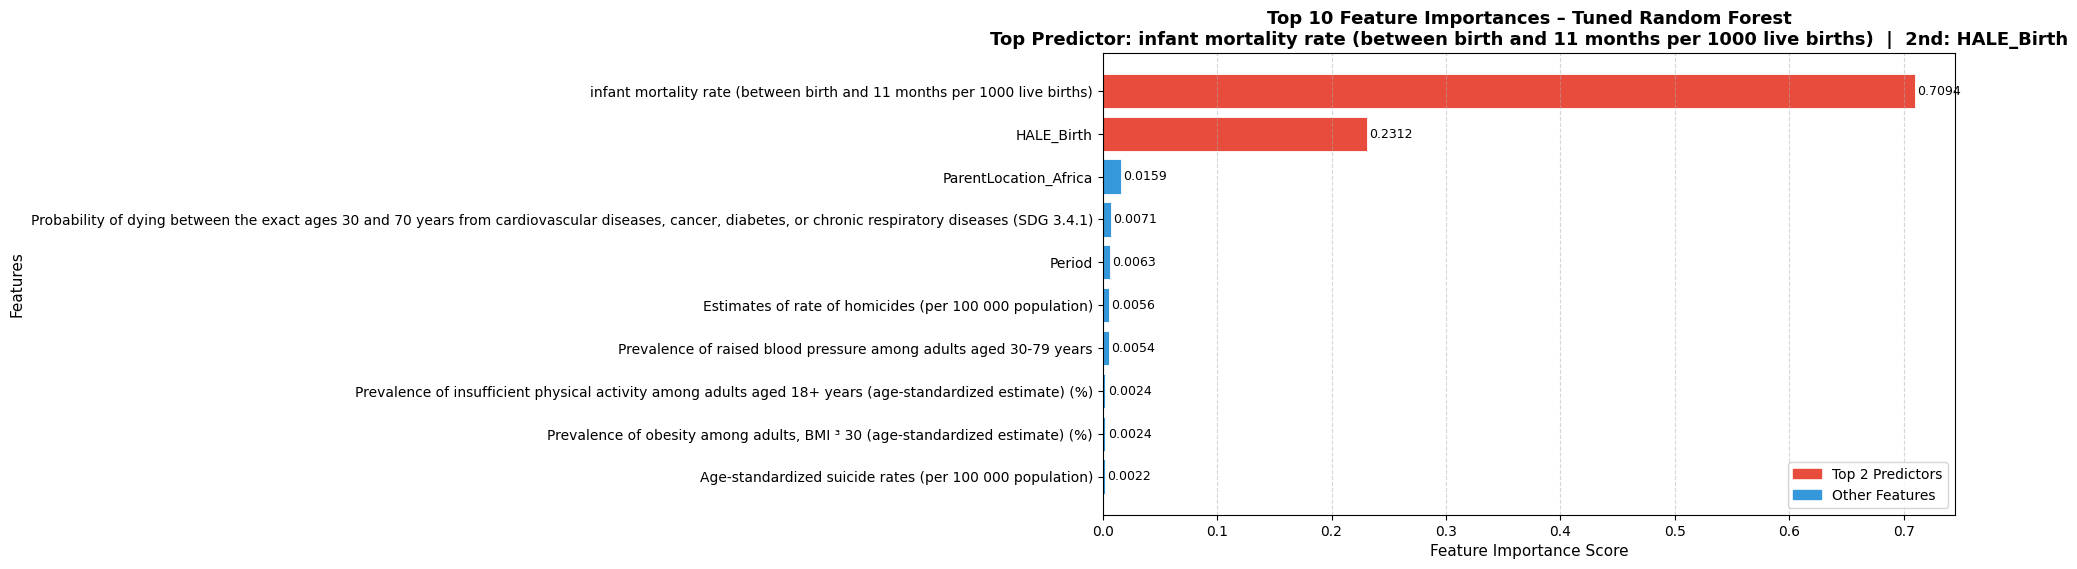

In [ ]:
# ── 3. Feature Importance Ranking ───────────────────────────
feature_importance_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\n Top 10 Feature Importances (Tuned Random Forest):")
print(feature_importance_df.head(10).to_string(index=False))

# Top 2 predictors
top1 = feature_importance_df.iloc[0]['Feature']
top2 = feature_importance_df.iloc[1]['Feature']
top1_imp = feature_importance_df.iloc[0]['Importance']
top2_imp = feature_importance_df.iloc[1]['Importance']

print(f"\n Top Predictor 1 : {top1}  (importance = {top1_imp:.4f})")
print(f" Top Predictor 2 : {top2}  (importance = {top2_imp:.4f})")

# Plot
colors = ['#e74c3c' if i < 2 else '#3498db'
          for i in range(min(10, len(feature_importance_df)))]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    feature_importance_df['Feature'][:10][::-1],
    feature_importance_df['Importance'][:10][::-1],
    color=colors[::-1], edgecolor='white', linewidth=0.6
)
for bar, val in zip(bars, feature_importance_df['Importance'][:10][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

red_patch  = mpatches.Patch(color='#e74c3c', label='Top 2 Predictors')
blue_patch = mpatches.Patch(color='#3498db', label='Other Features')
ax.legend(handles=[red_patch, blue_patch], fontsize=10)

ax.set_title('Top 10 Feature Importances – Tuned Random Forest\n'
             f'Top Predictor: {top1}  |  2nd: {top2}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_ylabel('Features', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()



 Regional Insight Summary:
                       Mean_Actual_HALE60  Mean_Predicted_HALE60  Mean_Top1  Mean_Top2  Count
Region                                                                                       
Africa                            -1.2041                -1.1998     1.1389    -0.9123   2820
South-East Asia                    0.0307                 0.0294     0.1896    -0.1135    660
Eastern Mediterranean              0.0332                 0.0329     0.0336    -0.1192   1320
Western Pacific                    0.2432                 0.2421    -0.3235    -0.0296   1260
Americas                           0.4623                 0.4688    -0.3849     0.6251   2040
Europe                             0.6940                 0.6864    -0.7294     0.5224   3000


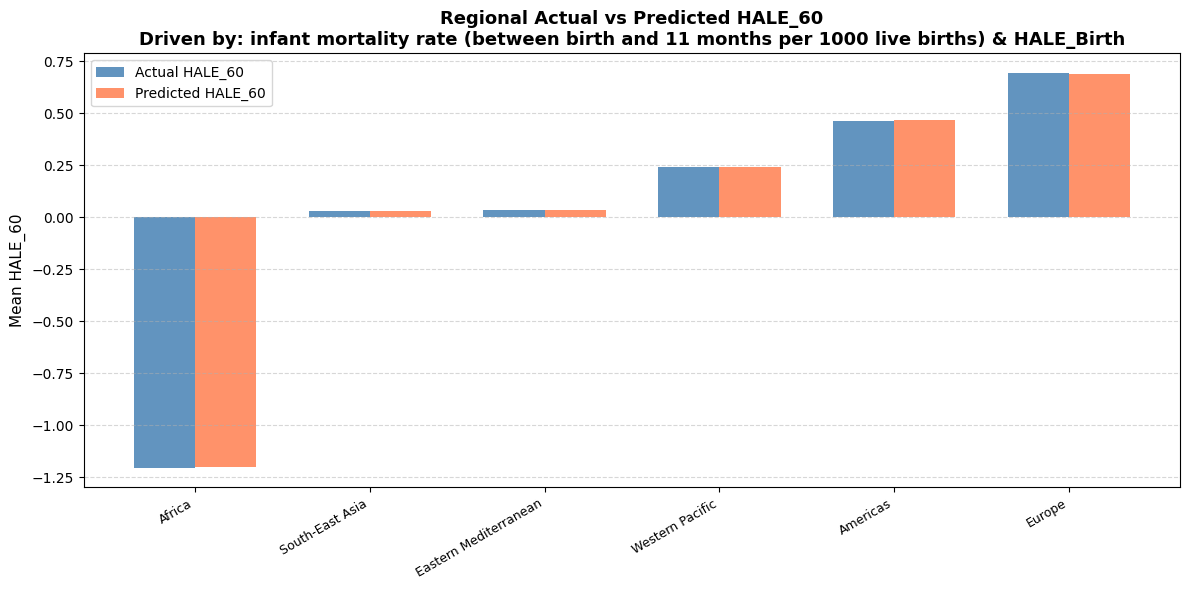

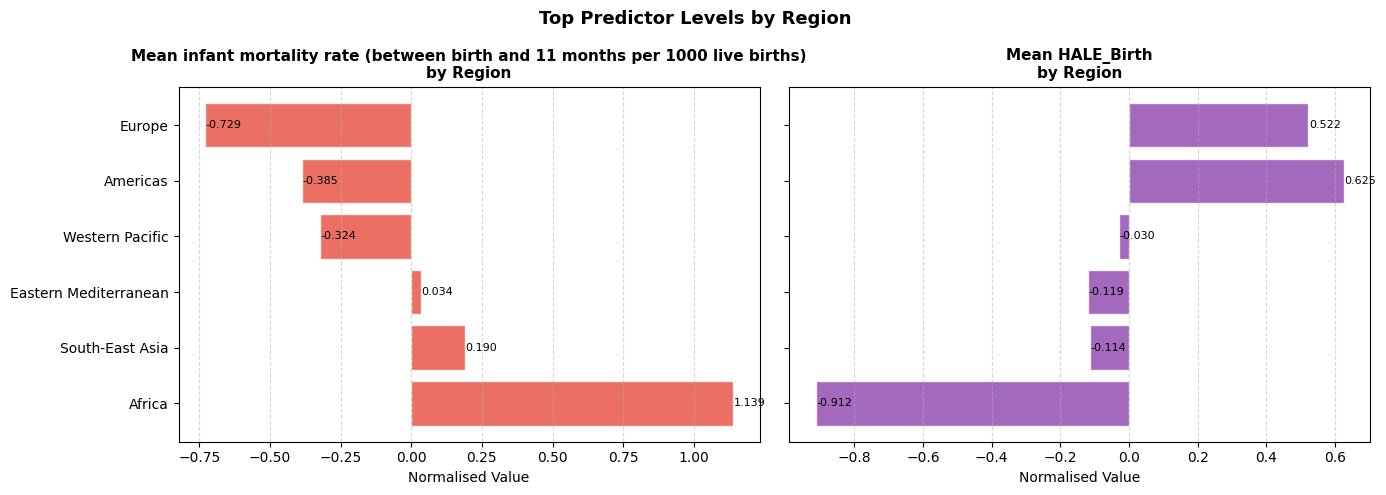

In [ ]:
# ── Reconstruct Region from one-hot encoded ParentLocation columns ──
parent_cols = [c for c in normalized_data.columns if c.startswith('ParentLocation_')]
normalized_data['Region'] = normalized_data[parent_cols].idxmax(axis=1)\
                            .str.replace('ParentLocation_', '')

region_col = 'Region'

# Attach predictions to full dataset
full_pred = rf_model.predict(X)
regional_df = normalized_data.copy()
regional_df['Predicted_HALE_60'] = full_pred
regional_df['Residual']          = full_pred - regional_df['HALE_60']

region_summary = (
    regional_df.groupby(region_col)
    .agg(
        Mean_Actual_HALE60    = ('HALE_60',           'mean'),
        Mean_Predicted_HALE60 = ('Predicted_HALE_60', 'mean'),
        Mean_Top1             = (top1,                'mean'),
        Mean_Top2             = (top2,                'mean'),
        Count                 = ('HALE_60',           'count')
    )
    .round(4)
    .sort_values('Mean_Actual_HALE60')
)

print("\n Regional Insight Summary:")
print(region_summary.to_string())

# Plot: Actual vs Predicted by region
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(region_summary))
w = 0.35
ax.bar(x_pos - w/2, region_summary['Mean_Actual_HALE60'],
       w, label='Actual HALE_60', color='steelblue', alpha=0.85)
ax.bar(x_pos + w/2, region_summary['Mean_Predicted_HALE60'],
       w, label='Predicted HALE_60', color='coral', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(region_summary.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Mean HALE_60', fontsize=11)
ax.set_title(f'Regional Actual vs Predicted HALE_60\n'
             f'Driven by: {top1} & {top2}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('regional_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot: Top predictors by region
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, col, color, label in [
    (axes[0], 'Mean_Top1', '#e74c3c', top1),
    (axes[1], 'Mean_Top2', '#8e44ad', top2),
]:
    bars = ax.barh(region_summary.index,
                   region_summary[col],
                   color=color, alpha=0.8, edgecolor='white')
    for bar, val in zip(bars, region_summary[col]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)
    ax.set_title(f'Mean {label}\nby Region', fontsize=11, fontweight='bold')
    ax.set_xlabel('Normalised Value', fontsize=10)
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle('Top Predictor Levels by Region', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('top_predictors_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 5. Policy Recommendations by Region ──────────────────
print("\n" + "=" * 60)
print("  POLICY RECOMMENDATIONS")
print(f"  Target: {top1} & {top2}")
print("=" * 60)

# Threshold: regions above median need more intervention
med_top1 = region_summary['Mean_Top1'].median()
med_top2 = region_summary['Mean_Top2'].median()

for region, row in region_summary.iterrows():
    flag1 = "HIGH" if row['Mean_Top1'] > med_top1 else "OK"
    flag2 = "HIGH" if row['Mean_Top2'] > med_top2 else "OK"

    print(f"\nRegion          : {region}")
    print(f"Actual HALE_60  : {row['Mean_Actual_HALE60']:.4f}")
    print(f"Predicted HALE_60: {row['Mean_Predicted_HALE60']:.4f}")
    print(f"{top1:<40}: {row['Mean_Top1']:.4f}  [{flag1}]")
    print(f"{top2:<40}: {row['Mean_Top2']:.4f}  [{flag2}]")

    recs = []
    if row['Mean_Top1'] > med_top1:
        recs.append(
            f"Reduce {top1}: Ensure 4+ antenatal visits & 100% institutional deliveries, Schedule postnatal visits (within 48 hrs, 7 days, 28 days) & achieve full immunization per World Health Organization, Provide iron–folic acid to mothers & promote exclusive breastfeeding for 6 months "

        )
    if row['Mean_Top2'] > med_top2:
        recs.append(
            f"Address {top2}: Upgrade primary health centers with essential drugs & staff, Ensure piped safe drinking water & household toilets, Implement cash transfers & girls’ education programs for low-income families"
        )
    if not recs:
        recs.append("Maintain current strategies; monitor for regression.")

    print("Recommendations:")
    for r in recs:
        print(f"  {r}")



  POLICY RECOMMENDATIONS
  Target: infant mortality rate (between birth and 11 months per 1000 live births) & HALE_Birth

Region          : Africa
Actual HALE_60  : -1.2041
Predicted HALE_60: -1.1998
infant mortality rate (between birth and 11 months per 1000 live births): 1.1389  [HIGH]
HALE_Birth                              : -0.9123  [OK]
Recommendations:
  Reduce infant mortality rate (between birth and 11 months per 1000 live births): Ensure 4+ antenatal visits & 100% institutional deliveries, Schedule postnatal visits (within 48 hrs, 7 days, 28 days) & achieve full immunization per World Health Organization, Provide iron–folic acid to mothers & promote exclusive breastfeeding for 6 months 

Region          : South-East Asia
Actual HALE_60  : 0.0307
Predicted HALE_60: 0.0294
infant mortality rate (between birth and 11 months per 1000 live births): 0.1896  [HIGH]
HALE_Birth                              : -0.1135  [OK]
Recommendations:
  Reduce infant mortality rate (between birth

In [ ]:
print(X.columns)


Index(['Period', 'HALE_Birth',
       'infant mortality rate (between birth and 11 months per 1000 live births)',
       'Age-standardized suicide rates (per 100 000 population)',
       'Alcohol, total per capita (15+ years) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2)',
       'Probability of dying between the exact ages 30 and 70 years from cardiovascular diseases, cancer, diabetes, or chronic respiratory diseases (SDG 3.4.1)',
       'Estimates of rate of homicides (per 100 000 population)',
       'Mean Total Cholesterol (crude estimate)',
       'Prevalence of insufficient physical activity among adults aged 18+ years (age-standardized estimate) (%)',
       'Prevalence of obesity among adults, BMI ³ 30 (age-standardized estimate) (%)',
       ...
       'Location_Vanuatu', 'Location_Venezuela (Bolivarian Republic of)',
       'Location_Viet Nam', 'Location_Yemen', 'Location_Zambia',
       'Location_Zimbabwe',
       'Location_occupied Palestinian territory, inc

In [ ]:
#  6. Single Test Set Instance Prediction

sample_index = 2483
single_test_instance = X_test.loc[[sample_index]]
actual_value = y_test.loc[sample_index]
predicted_value = rf_model.predict(single_test_instance)[0]

print(f"  Instance Index   : {sample_index}")
print(f"  Year             : {int(single_test_instance['Period'].values[0])}")
print(f"  HALE_Birth       : {single_test_instance['HALE_Birth'].values[0]:.4f} ")
print(f"  Infant Mortality : {single_test_instance['infant mortality rate (between birth and 11 months per 1000 live births)'].values[0]:.4f}  ")
print(f"  Actual HALE_60   : {actual_value:.4f}")
print(f"  Predicted HALE_60: {predicted_value:.4f}")
print(f"  Residual (Δ)     : {predicted_value - actual_value:.4f}")


  Instance Index   : 2483
  Year             : 2007
  HALE_Birth       : 0.7824 
  Infant Mortality : -0.8683  
  Actual HALE_60   : 0.8852
  Predicted HALE_60: 0.8535
  Residual (Δ)     : -0.0317


In [ ]:
import pandas as pd

custom_instance = X_test.iloc[[0]].copy()


custom_instance.loc[:, 'HALE_Birth'] = 1.0   # high
custom_instance.loc[:, 'infant mortality rate (between birth and 11 months per 1000 live births)'] = -1.0  # low
custom_instance.loc[:, 'Period'] = 0.5  # slightly above average year

custom_prediction = rf_model.predict(custom_instance)[0]

print("Modified Features:")
print(f"  Year (scaled)     : {custom_instance['Period'].values[0]:.4f}")
print(f"  HALE_Birth        : {custom_instance['HALE_Birth'].values[0]:.4f}")
print(f"  Infant Mortality  : {custom_instance['infant mortality rate (between birth and 11 months per 1000 live births)'].values[0]:.4f}")

print("\nPredicted HALE_60 (Z-score): {:.4f}".format(custom_prediction))



Modified Features:
  Year (scaled)     : 0.5000
  HALE_Birth        : 1.0000
  Infant Mortality  : -1.0000

Predicted HALE_60 (Z-score): 0.9264


/tmp/ipykernel_4552/3744949311.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  custom_instance.loc[:, 'Period'] = 0.5  # slightly above average year
